In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate, differentiate

https://stackoverflow.com/questions/79689325/differentiating-odesolution-object

In [2]:
def model(t, y): 
    return 0.5 * y

In [3]:
t = np.linspace(0, 2, 500)

In [4]:
solution = integrate.solve_ivp(model, [t.min(), t.max()], y0=[1.], t_eval=t, dense_output=True)
solution

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  4.008e-03 ...  1.996e+00  2.000e+00]
        y: [[ 1.000e+00  1.002e+00 ...  2.713e+00  2.718e+00]]
      sol: <scipy.integrate._ivp.common.OdeSolution object at 0x7f6b243112d0>
 t_events: None
 y_events: None
     nfev: 20
     njev: 0
      nlu: 0

In [5]:
gradient = np.gradient(solution.y[0], solution.t)

In [6]:
@np.vectorize
def f(t):
    return solution.sol(t)[0]

In [7]:
derivative = differentiate.derivative(f, t)
derivative

     success: [ True  True ...  True  True]
      status: [0 0 ... 0 0]
          df: [ 5.000e-01  5.010e-01 ...  1.356e+00  1.359e+00]
       error: [ 1.112e-09  4.324e-09 ...  2.220e-16  4.219e-15]
         nit: [3 3 ... 2 2]
        nfev: [13 13 ... 11 11]
           x: [ 0.000e+00  4.008e-03 ...  1.996e+00  2.000e+00]

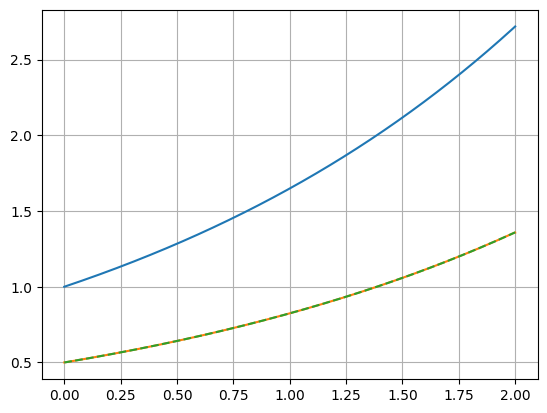

In [8]:
fig, axe = plt.subplots()
axe.plot(solution.t, solution.y[0])
axe.plot(solution.t, gradient)
axe.plot(solution.t, derivative.df, "--")
axe.grid()

In [9]:
fig.savefig("test.png")